<a href="https://colab.research.google.com/github/p-garden/p-garden/blob/main/8week_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1번 문제**

## 문제내용

**맞는 문장이면 O,** **틀린문장이 있다면 고쳐주세요.**

1. 인공 신경망 모델이 최적화하는 대상은 정확도이므로 모델이 잘 훈련되었는지 판단하려면 정확도를 확인해야 한다.
2. SGD 클래스의 momentum 매개변수를 기본값으로 사용하면 모멘텀 최적화를 사용한다.
3. 드롭아웃은 과대적합을 막는 방법으로 훈련이 끝난 뒤에 적용한다.
4. Dense 층은 Flatten 층과 마찬가지로 입력의 차원을 변형하여 계산한다.
5. 원-핫 인코딩이 필요한 이유는 다중 분류를 사용할 때, 출력충에서 만든 확률과 크로스 엔트로피 손실을 계산히기 위해서이다.
6. 하이퍼파라미터는 모델이 직접 학습하여 사람이 지정해 주지 않아도 되는 파라미터이다.


1. X / 인공 신경망 모델이 최적화하는 대상은 손실함수이므로 모델이 잘 훈련되었는지 판단하려면 손실함수의 값을 확인해야 한다
2. X / 기본값보다 큰 수를 지정하면
3. X / 훈련 전에 적용
4. X / 입력차원을 변형시키지 않고 활성화 함수를 적용
5. O
6. X / 사용자가 직접 지정해야하는 파라미터

# **문제 2**

## 문제내용

1. 기존의 활성화 함수(sigmoid) 는 기울기 소실 문제가 발생합니다. 기울기 소실 문제가 발생하는 이유와 이를 해결한 ReLU 함수의 해결 방식에 대해 설명해주세요. 
2. 다음과 같이 콜백 코드를 작성했을 때 발생하는 문제점을 설명해주세요.

#X는 임의의 숫자
callbacks = [ 
  
    EarlyStopping(patience=X, restore_best_weights=True),
    ModelCheckpoint('best-weights.h5')
]

model.fit(..., callbacks=callbacks)

1. 시그모이드 함수는 극단으로 갈수록 그래프가 누워있어, 큰차이를 만들어내지 못한다. 게다가, 시그모이드 함수를 여러층에서 사용하면 기울기 소실이 배가되어 학습이 어렵다. relu함수는 음수는 0으로, 양수는 함수가 없는 것처럼 보이는 함수로 큰 차이를 만들어낼 수 있다.

2. callbacks라는 함수안에 조기종료 관련 모듈을 넣어 작동시킬 경우, 정상적으로 작동은 하지만 조기종료 및 체크포인트 변수를 선언하지 않아 이를 활용하기는 어렵다는 단점이 있다. (?)

=> monitor 인수를 설정하지 않아서 최적의 모델의 가중치를 계속 저장할 수 없다

# **3번 문제**

In [ ]:
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

iris = load_iris()
X = iris.data
y = iris.target

# StandardScaler를 이용해 데이터 전처리
ss = StandardScaler()
ss.fit(X)
train_scaled = ss.transform(X)

# 데이터 나누기 (test 데이터 비율 : 0.2, random_state = 42)
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, y, test_size=0.2, random_state=42)

# 모델 생성
#첫 번째 dense 층은 16개의 뉴런과 relu 활성화 함수를 사용. 두 번째 dense 층은 3개의 뉴런과 softmax 활성화 함수를 사용
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(16,activation='relu' ,input_shape=(4,)),
    tf.keras.layers.Dense(3, activation='softmax')
])

# 모델 컴파일 : adam optimizer 사용, sparse categorical crossentropy 손실함수 사용, 모델 평가 지표는 정확도 사용
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics='accuracy')

# 모델 학습 : X_train, y_train을 이용해 모델을 20번 학습하고, X_test와 y_test로 검증
model.fit(train_scaled, train_target, epochs=20)

# 모델 평가
test_loss, test_acc = model.evaluate(val_scaled, val_target)
print('Test accuracy:', test_acc)


(150, 4)
Epoch 1/20
4/4 [==============================] - 2s 7ms/step - loss: 1.1257 - accuracy: 0.3167
Epoch 2/20
4/4 [==============================] - 0s 4ms/step - loss: 1.0826 - accuracy: 0.3583
Epoch 3/20
4/4 [==============================] - 0s 4ms/step - loss: 1.0441 - accuracy: 0.3833
Epoch 4/20
4/4 [==============================] - 0s 4ms/step - loss: 1.0057 - accuracy: 0.4500
Epoch 5/20
4/4 [==============================] - 0s 4ms/step - loss: 0.9686 - accuracy: 0.5500
Epoch 6/20
4/4 [==============================] - 0s 4ms/step - loss: 0.9340 - accuracy: 0.6250
Epoch 7/20
4/4 [==============================] - 0s 7ms/step - loss: 0.8995 - accuracy: 0.6583
Epoch 8/20
4/4 [==============================] - 0s 5ms/step - loss: 0.8686 - accuracy: 0.6667
Epoch 9/20
4/4 [==============================] - 0s 8ms/step - loss: 0.8392 - accuracy: 0.6833
Epoch 10/20
4/4 [==============================] - 0s 8ms/step - loss: 0.8112 - accuracy: 0.7000
Epoch 11/20
4/4 [=============

# **문제 4**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

# 패션 MNIST 데이터셋을 로드합니다.
(train_images, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()

# 데이터를 전처리하고 훈련 세트와 검증 세트로 분리합니다.
train_images = train_images / 255.0
train_images, val_images, train_labels, val_labels = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)

# 모델을 정의합니다.
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])


# 모델을 훈련 시킵니다.
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.h5')
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
history = model.fit(train_images, train_labels, epochs=20, validation_data=(val_images, val_labels), callbacks=[checkpoint_cb, early_stopping_cb])



# 검증 세트의 성능을 평가합니다.
model.evaluate(val_images, val_labels)



Epoch 1/20
1500/1500 [==============================] - 7s 4ms/step - loss: 0.5795 - accuracy: 0.7952 - val_loss: 0.4201 - val_accuracy: 0.8478
Epoch 2/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.4298 - accuracy: 0.8450 - val_loss: 0.3811 - val_accuracy: 0.8611
Epoch 3/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3939 - accuracy: 0.8554 - val_loss: 0.3669 - val_accuracy: 0.8651
Epoch 4/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3753 - accuracy: 0.8630 - val_loss: 0.3474 - val_accuracy: 0.8727
Epoch 5/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3568 - accuracy: 0.8693 - val_loss: 0.3413 - val_accuracy: 0.8742
Epoch 6/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3442 - accuracy: 0.8730 - val_loss: 0.3277 - val_accuracy: 0.8812
Epoch 7/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3315 - accuracy: 0.8774 - val_loss: 0.3276 - val_accuracy:

[0.3132858872413635, 0.8855833411216736]

활성화 함수를 시그모이드 -> relu함수로 변경

드롭아웃 층 생성

훈련횟수를 5회 -> 20회로 증가

과대적합 방지 위해 콜백 추가

0.87 -> 0.88

# **문제 5**


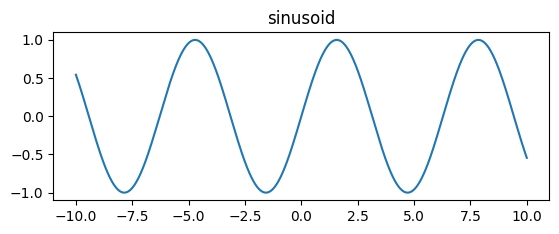

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 512)               1024      
                                                                 
 dropout_1 (Dropout)         (None, 512)               0         
                                                                 
 dense_3 (Dense)             (None, 512)               262656    
                                                                 
 dropout_2 (Dropout)         (None, 512)               0         
                                                                 
 dense_4 (Dense)             (None, 512)               262656    
                                                                 
 dropout_3 (Dropout)         (None, 512)               0         
                                                                 
 dense_5 (Dense)             (None, 1)                

In [16]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(-10, 10, 10000)
y=np.sin(x)

plt.subplot(2,1,1)
plt.title("sinusoid")
plt.plot(x[0 : 10000],y[0 : 10000])
plt.show()

from keras.models import Sequential
from keras.layers import Dense, Dropout

model2=Sequential(
    [
        Dense(512,input_shape=(1,),activation='relu'),
        Dropout(0.2),
        Dense(512,activation='relu'),
        Dropout(0.2),
        Dense(512,activation='relu'),
        Dropout(0.2),
        Dense(1)
])

model2.build()
model2.summary()

In [17]:
from tensorflow.keras.utils import plot_model
plot_model(model2, show_shapes=True, to_file='model2_1.png')

from sklearn.model_selection import train_test_split
print(x.shape,y.shape)

X=np.array([x])
Y=np.array([y])
X=X.T
Y=Y.T
print(X.shape,Y.shape)

train_x,validation_x,train_y,validation_y = train_test_split(X,Y,train_size=0.7,shuffle=True)

(10000,) (10000,)
(10000, 1) (10000, 1)


In [18]:
from tensorflow import keras

training_epochs=200
num_batch_size=50

learning_rate=0.0005
opt=keras.optimizers.Adam(learning_rate=learning_rate)
rms = keras.optimizers.RMSprop(lr=0.01, rho=0.9, epsilon=1e-08)

model2.compile(loss='mse',optimizer=opt,metrics=['mse','mae'])
from keras.callbacks import EarlyStopping
#문제 : 조기종료 Earlystopping을 구현하세요.
#조건 1 : moniter = "val_mae", mode = "min"
#조건 2 : patience = 20
#조건 3 : restore_best_weights = True
"""여기에 작성"""


early_stopping = keras.callbacks.EarlyStopping(patience=20,restore_best_weights=True, monitor='val_name', mode='min' )

#문제 : 모델 체크포인트 저장을 구현하세요.
#조건 1 : 저장파일 이름 = 'sin.h5'
#조건 2 : moniter와 mode는 조기종료와 동일하게 설정할 것
#조건 3 : save_weights_only=False
#조건 4 : save_best_only=True
"""여기에 작성"""

check_point=keras.callbacks.ModelCheckpoint('sin.h5',
                                            save_best_only=True,
                                            save_weights_only=False,
                                            monitor='val_mae',
                                            mode="min")



history=model2.fit(train_x,train_y,shuffle=True,validation_data=(validation_x, validation_y),batch_size=num_batch_size,epochs=training_epochs,callbacks=[check_point,early_stopping])

Epoch 1/200
138/140 [============================>.] - ETA: 0s - loss: 0.4795 - mse: 0.4795 - mae: 0.6076

140/140 [==============================] - 4s 16ms/step - loss: 0.4797 - mse: 0.4797 - mae: 0.6078 - val_loss: 0.4656 - val_mse: 0.4656 - val_mae: 0.5899
Epoch 2/200
139/140 [============================>.] - ETA: 0s - loss: 0.4260 - mse: 0.4260 - mae: 0.5643

140/140 [==============================] - 3s 23ms/step - loss: 0.4247 - mse: 0.4247 - mae: 0.5631 - val_loss: 0.3233 - val_mse: 0.3233 - val_mae: 0.4633
Epoch 3/200
139/140 [============================>.] - ETA: 0s - loss: 0.2703 - mse: 0.2703 - mae: 0.4218

140/140 [==============================] - 3s 20ms/step - loss: 0.2695 - mse: 0.2695 - mae: 0.4210 - val_loss: 0.1483 - val_mse: 0.1483 - val_mae: 0.2844
Epoch 4/200
139/140 [============================>.] - ETA: 0s - loss: 0.1798 - mse: 0.1798 - mae: 0.3319

140/140 [==============================] - 2s 15ms/step - loss: 0.1801 - mse: 0.1801 - mae: 0.3323 - val_loss: 0.1083 - val_mse: 0.1083 - val_mae: 0.2273
Epoch 5/200
138/140 [============================>.] - ETA: 0s - loss: 0.1466 - mse: 0.1466 - mae: 0.2962

...

140/140 [==============================] - 3s 21ms/step - loss: 0.0055 - mse: 0.0055 - mae: 0.0584 - val_loss: 0.0029 - val_mse: 0.0029 - val_mae: 0.0390
Epoch 197/200
137/140 [============================>.] - ETA: 0s - loss: 0.0056 - mse: 0.0056 - mae: 0.0580

140/140 [==============================] - 3s 19ms/step - loss: 0.0055 - mse: 0.0055 - mae: 0.0579 - val_loss: 0.0011 - val_mse: 0.0011 - val_mae: 0.0252
Epoch 198/200
140/140 [==============================] - ETA: 0s - loss: 0.0054 - mse: 0.0054 - mae: 0.0579

140/140 [==============================] - 2s 15ms/step - loss: 0.0054 - mse: 0.0054 - mae: 0.0579 - val_loss: 0.0021 - val_mse: 0.0021 - val_mae: 0.0327
Epoch 199/200
140/140 [==============================] - ETA: 0s - loss: 0.0055 - mse: 0.0055 - mae: 0.0579

140/140 [==============================] - 2s 16ms/step - loss: 0.0055 - mse: 0.0055 - mae: 0.0579 - val_loss: 0.0021 - val_mse: 0.0021 - val_mae: 0.0341
Epoch 200/200
139/140 [============================>.] - ETA: 0s - loss: 0.0057 - mse: 0.0057 - mae: 0.0586

140/140 [==============================] - 2s 17ms/step - loss: 0.0057 - mse: 0.0057 - mae: 0.0585 - val_loss: 0.0031 - val_mse: 0.0031 - val_mae: 0.0399


In [19]:
def vis(history,name) :
    plt.title(f"{name.upper()}")
    plt.xlabel('epochs')
    plt.ylabel(f"{name.lower()}")
    value = history.history.get(name)
    val_value = history.history.get(f"val_{name}",None)
    epochs = range(1, len(value)+1)
    plt.plot(epochs, value, 'b-', label=f'training {name}')
    if val_value is not None :
        plt.plot(epochs, val_value, 'r:', label=f'validation {name}')
    plt.legend(loc='upper center', bbox_to_anchor=(0.05, 1.2) , fontsize=10 , ncol=1)

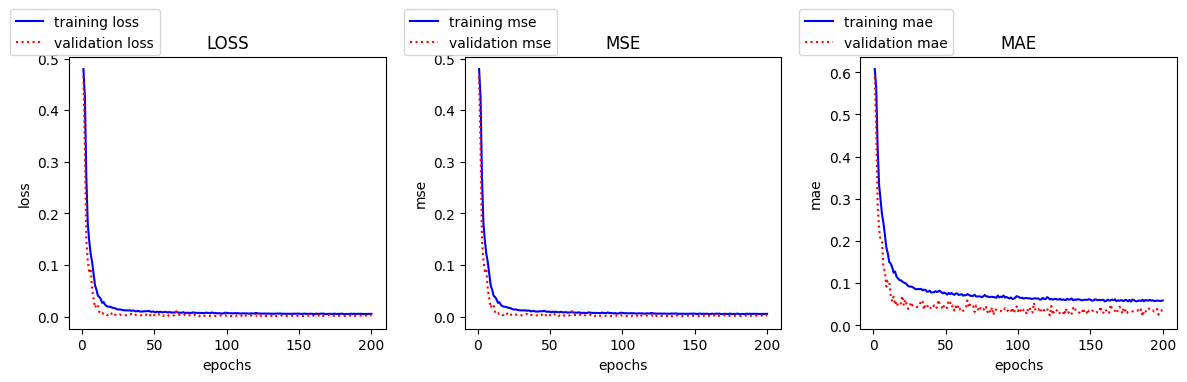

In [20]:
def plot_history(history):
  key_value=list(set([i.split("val_")[-1] for i in list(history.history.keys())]))
  plt.figure(figsize=(12,4))
  for idx, key in enumerate(key_value):
    plt.subplot(1,len(key_value),idx+1)
    vis(history,key)
    
  plt.tight_layout()
  plt.show()

plot_history(history)

In [21]:
test_x=np.linspace(-20, 20, 20000)
test_y=np.sin(test_x)

test_X=np.array([test_x])
test_Y=np.array([test_y])
test_X = test_X.T
test_Y = test_Y.T

#test_X를 입력으로 모델에 넣어 출력값을 내봅시다.
"""여기에 작성"""
test_pred = model2.predict(test_X)


625/625 [==============================] - 2s 3ms/step


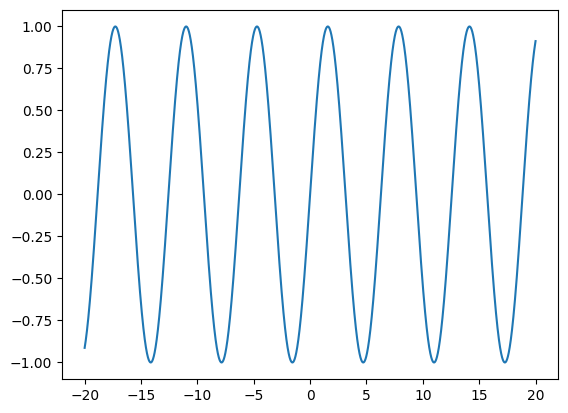

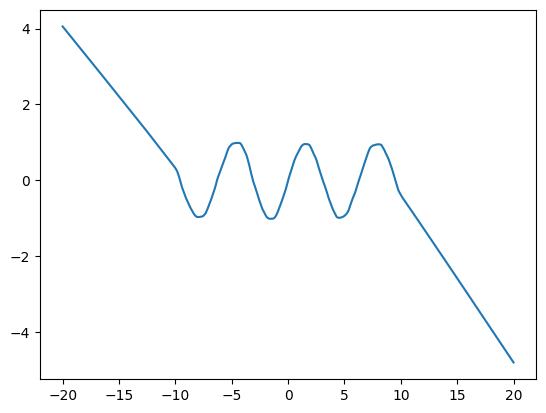

In [22]:
#입력값에 대한 실제 사인값 그래프
plt.plot(test_X,test_Y)
plt.show()

#입력값에 대한 출력값 그래프
plt.plot(test_X,test_pred)
plt.show()

In [23]:

#이 때, 기존 "model2" 를 써도 되지만, 원하는 만큼 dropout을 적용하려면 기존 모델과 같은 구조에
#dropout정도를 변경해서 쓸 수 있습니다.
new_model=Sequential(
    [
        Dense(512,input_shape=(1,),activation='relu'),
        Dropout(0.3),
        Dense(512,activation='relu'),
        Dropout(0.3),
        Dense(512,activation='relu'),
        Dropout(0.3),
        Dense(1)
])

#그리고 해당 모델 구조(new_model)에 기존에 저장한 sin.h5를 불러와봅시다.
"""여기에 작성"""
new_model.load_weights('sin.h5')

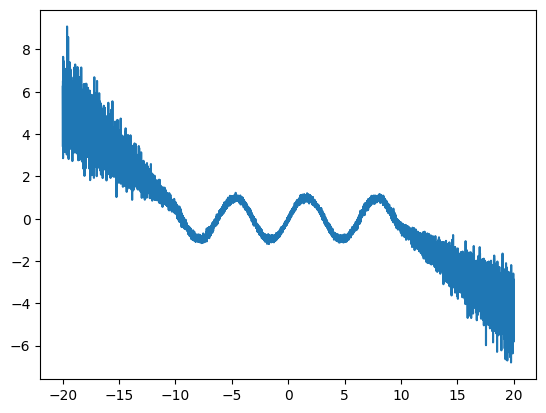

In [24]:
#test에서 dropout을 적용한 상태로 돌려봅시다.
#주의 : 이부분이 핵심입니다. dropout을 킨 상태로 test를 돌려야 합니다.
#Hint : https://keras.io/api/layers/regularization_layers/dropout/
#Hint2 : Model.predict()쓰면 안됨.
"""여기에 작성"""
test_pred_with_dropout = new_model(test_X, training=True)


plt.plot(test_X,test_pred_with_dropout)
plt.show()


In [ ]:
# dropout을 적용시켜 test데이터에 대한 결과를 50번 뽑아내세요. 물론 더 많이 뽑아도 됩니다.
# 해당 결과에 대한 평균과 분산을 시각화 하세요.
import numpy as np
def mc_dropout_predict(model, x, n=50):
    """여기에 작성"""
    preds = []
    for i in range(n):
      res = model(x,training=True)
      preds.append(res)
    avg_pred = np.mean(preds,axis=0)
    var_pred = np.var(preds, axis=0)
    
    
    return avg_pred, var_pred


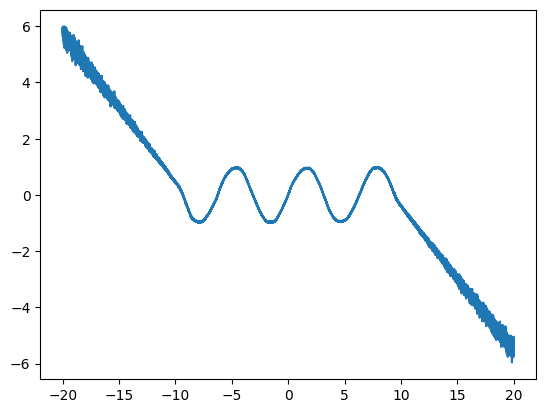

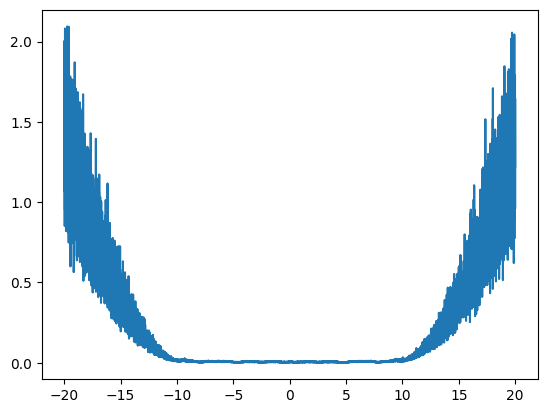

In [ ]:
test_pred_avg, test_pred_var =  mc_dropout_predict(new_model, test_X, n=50)

plt.plot(test_X,test_pred_avg)
plt.show()

plt.plot(test_X,test_pred_var)
plt.show()